In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [32]:
def logic_gate(x1, x2, gate):

    if gate == "AND":
        return int(x1 == 1 and x2 == 1)

    elif gate == "OR":
        return int(x1 == 1 or x2 == 1)

    elif gate == "XOR":
        return int(x1 != x2)



In [47]:
and_arr = {}
or_arr = {}
xor_arr = {}

and_arr["input1"] = [1,1,0,0]
and_arr["input2"] = [1,0,1,0]

or_arr["input1"] = [1,1,0,0]
or_arr["input2"] = [1,0,1,0]

xor_arr["input1"] = [1,1,0,0]
xor_arr["input2"] = [1,0,1,0]

# Vectorize the logic_gate function to handle array inputs
vectorized_logic_gate = np.vectorize(logic_gate)

and_output = vectorized_logic_gate(and_arr["input1"], and_arr["input2"],"AND")
or_output =  vectorized_logic_gate(or_arr["input1"], or_arr["input2"], "OR")
xor_output = vectorized_logic_gate(xor_arr["input1"], xor_arr["input2"], "XOR")

and_df = pd.DataFrame(and_arr)
or_df = pd.DataFrame(or_arr)
xor_df = pd.DataFrame(xor_arr)

and_df["output"] = and_output
or_df["output"] = or_output
xor_df["output"] = xor_output


In [48]:
def plot(X,Y,Z):
  return sns.scatterplot(x=X, y=Y, hue=Z)

<Axes: xlabel='input1', ylabel='input2'>

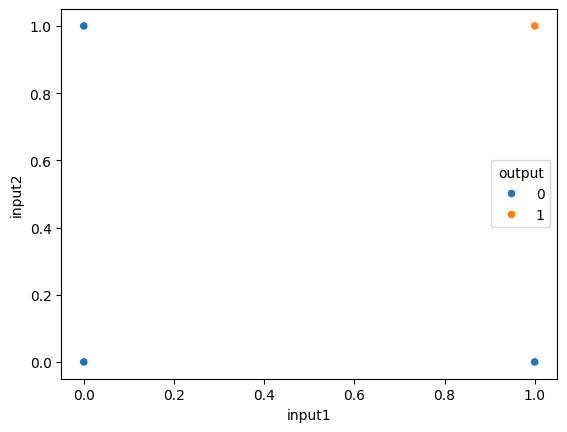

In [50]:
plot(and_df["input1"], and_df["input2"],and_df["output"])

<Axes: xlabel='input1', ylabel='input2'>

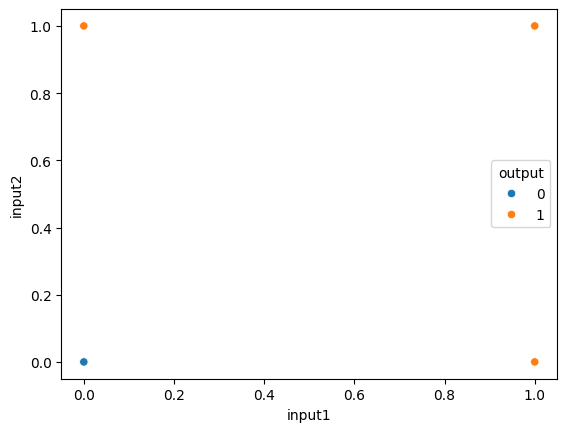

In [51]:
plot(or_df["input1"], or_df["input2"],or_df["output"])


<Axes: xlabel='input1', ylabel='input2'>

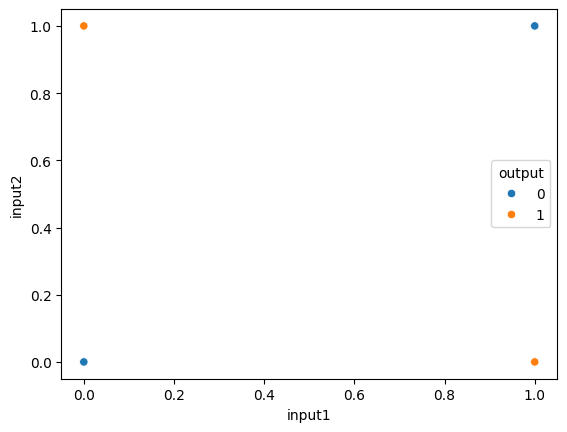

In [52]:
plot(xor_df["input1"], xor_df["input2"],xor_df["output"])


In [54]:
from sklearn.linear_model import Perceptron
clf1 = Perceptron()
clf2 = Perceptron()
clf3 = Perceptron()

In [65]:
and_res = clf1.fit(and_df[["input1", "input2"]], and_df["output"])

or_res = clf2.fit(or_df[["input1", "input2"]], or_df["output"])

xor_res = clf3.fit(xor_df[["input1", "input2"]], xor_df["output"])

### Perceptron Line for AND Gate

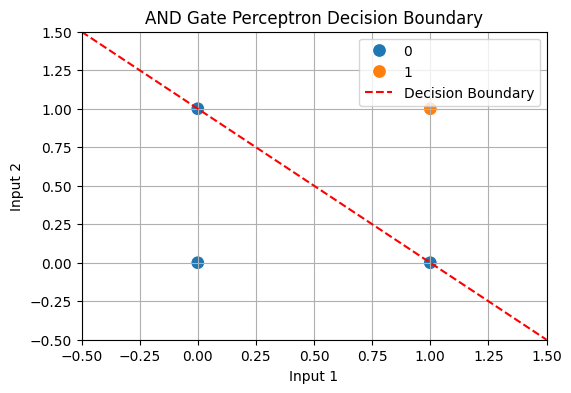

In [70]:
# Get coefficients and intercept for AND gate
w1_and, w2_and = and_res.coef_[0]
b_and = and_res.intercept_[0]

# Calculate slope (m) and y-intercept (c) for the decision boundary line
m_and = -(w1_and / w2_and)
c_and = -(b_and / w2_and)

x_input_and = np.linspace(-0.5, 1.5, 100) # Adjust range based on input data
y_input_and = m_and * x_input_and + c_and

plt.figure(figsize=(6, 4))
sns.scatterplot(x='input1', y='input2', hue='output', data=and_df, s=100)
plt.plot(x_input_and, y_input_and, color='red', linestyle='--', label='Decision Boundary')
plt.title('AND Gate Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.legend()
plt.grid(True)
plt.show()

### Perceptron Line for OR Gate

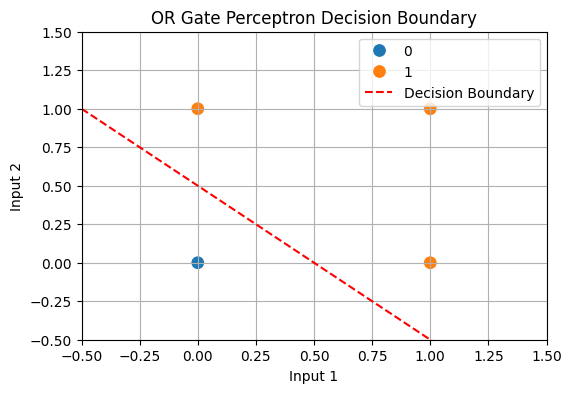

In [67]:
# Get coefficients and intercept for OR gate
w1_or, w2_or = or_res.coef_[0]
b_or = or_res.intercept_[0]

# Calculate slope (m) and y-intercept (c) for the decision boundary line
m_or = -(w1_or / w2_or)
c_or = -(b_or / w2_or)

x_input_or = np.linspace(-0.5, 1.5, 100) # Adjust range based on input data
y_input_or = m_or * x_input_or + c_or

plt.figure(figsize=(6, 4))
sns.scatterplot(x='input1', y='input2', hue='output', data=or_df, s=100)
plt.plot(x_input_or, y_input_or, color='red', linestyle='--', label='Decision Boundary')
plt.title('OR Gate Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.legend()
plt.grid(True)
plt.show()

### Perceptron Line for XOR Gate

/tmp/ipykernel_7475/83890965.py:8: RuntimeWarning: invalid value encountered in scalar divide
  m_xor = -(w1_xor / w2_xor)
/tmp/ipykernel_7475/83890965.py:9: RuntimeWarning: invalid value encountered in scalar divide
  c_xor = -(b_xor / w2_xor)


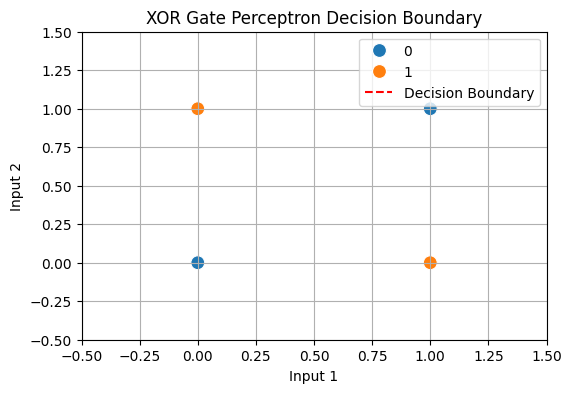

In [68]:
# Get coefficients and intercept for XOR gate
w1_xor, w2_xor = xor_res.coef_[0]
b_xor = xor_res.intercept_[0]

m_xor = -(w1_xor / w2_xor)
c_xor = -(b_xor / w2_xor)

x_input_xor = np.linspace(-0.5, 1.5, 100) # Adjust range based on input data
y_input_xor = m_xor * x_input_xor + c_xor

plt.figure(figsize=(6, 4))
sns.scatterplot(x='input1', y='input2', hue='output', data=xor_df, s=100)
plt.plot(x_input_xor, y_input_xor, color='red', linestyle='--', label='Decision Boundary')
plt.title('XOR Gate Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.legend()
plt.grid(True)
plt.show()